# Who Gets Mentioned?

In [ ]:
%matplotlib inline
import sys, json, re, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from IPython.display import display

SRC = Path("../src")
sys.path.insert(0, str(SRC))

from config import (RESULT_DIRS, CONDITION_LABELS, OUTPUT_DIR,
                    available_result_dirs, EVAL_K, N_RUNS)
from utils import (
    load_results_json, extract_metrics, load_past_visit_metrics_json,
    load_user_metadata, load_tweet_metadata,
    load_past_visit_preds, load_single_run_preds, load_gnn_preds,
    load_mention_rel, split_mention_rel, username_to_user_idx,
    compute_train_indegree, reconstruct_user_mention_test_table,
)

# ── shared palette / constants ───────────────────────────────────────────────
ACTOR_ORDER = ["politician", "journalist", "scientist/academic",
               "ngo", "activist", "organization", "citizen", "inactive"]
ACTOR_COLORS = {
    "politician": "#E91E63", "journalist": "#9C27B0",
    "scientist/academic": "#3F51B5", "ngo": "#00BCD4",
    "activist": "#4CAF50", "organization": "#FF9800",
    "citizen": "#795548", "inactive": "#9E9E9E",
}
GNN_COLOR, PV_COLOR = "#FF5722", "#2196F3"

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
warnings.filterwarnings("ignore", category=FutureWarning)

print("Setup complete.  Output root:", OUTPUT_DIR)

from utils import load_community_data  # needed for some helpers
OUT = OUTPUT_DIR / "B_who_gets_mentioned"
OUT.mkdir(parents=True, exist_ok=True)

results_tm = RESULT_DIRS["tweet_mention_orig"]
results_um = RESULT_DIRS["user_mention_orig"]
user_meta  = load_user_metadata(results_tm)
print(f"user_meta: {len(user_meta):,} users")

Setup complete.  Output root: /Users/zhangkexin/Desktop/TP/TP_link_prediction_analysis/analysis_output
user_meta: 229,849 users


## Shared helpers

In [52]:
# ── helpers ──────────────────────────────────────────────────────────────────
def user_idx_to_meta(idx_array, user_meta):
    flat = idx_array.flatten()
    mask = (flat >= 0) & (flat < len(user_meta))
    return user_meta.loc[flat[mask], ["actor_type", "verified"]]

def actor_type_counts(idx_array, user_meta, normalise=True):
    meta   = user_idx_to_meta(idx_array, user_meta)
    counts = meta["actor_type"].value_counts()
    for t in ACTOR_ORDER:
        if t not in counts: counts[t] = 0
    counts = counts.reindex(ACTOR_ORDER)
    return counts / counts.sum() if normalise else counts

def gt_user_idx_test(user_meta):
    mr = load_mention_rel()
    _, _, test_mr = split_mention_rel(mr)
    mapped = username_to_user_idx(test_mr["user_idx"], user_meta)
    return mapped.dropna().astype(int).values

pv_tm  = load_past_visit_preds(results_tm, "test")
pv_um  = load_past_visit_preds(results_um, "test")
gnn_um = load_single_run_preds(results_um, run_id=1, split="test", epoch_key="best_map")
gt_idx = gt_user_idx_test(user_meta)
print(f"GT test users: {len(gt_idx):,} | PV-TM preds: {pv_tm.shape} | PV-UM: {pv_um.shape}")


GT test users: 57,367 | PV-TM preds: (29537, 10) | PV-UM: (18977, 10)


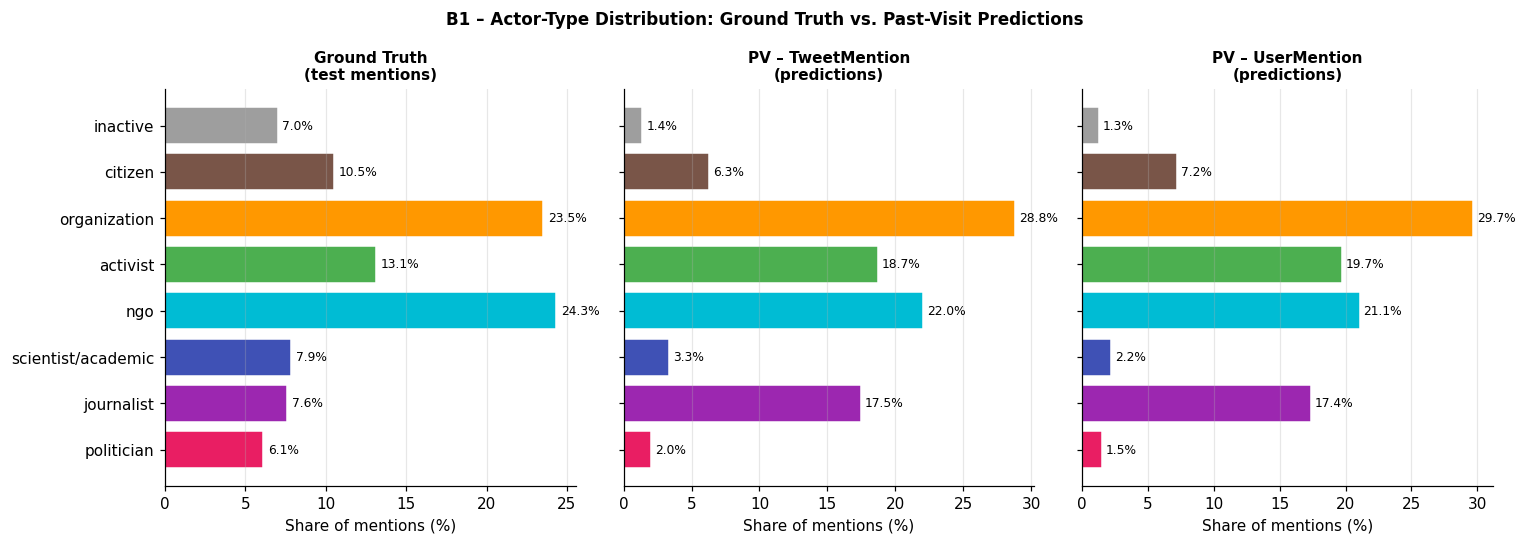

Saved actor_type_shares.csv


In [53]:
distributions = {
    "Ground Truth\n(test mentions)":       actor_type_counts(gt_idx,  user_meta),
    "PV – TweetMention\n(predictions)":   actor_type_counts(pv_tm,   user_meta),
    "PV – UserMention\n(predictions)":    actor_type_counts(pv_um,   user_meta),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle("B1 – Actor-Type Distribution: Ground Truth vs. Past-Visit Predictions",
             fontsize=11, fontweight="bold")
for ax, (title, dist) in zip(axes, distributions.items()):
    colors = [ACTOR_COLORS.get(t, "#BDBDBD") for t in dist.index]
    bars   = ax.barh(dist.index, dist.values * 100, color=colors, edgecolor="white")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Share of mentions (%)")
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.3)
    for bar, val in zip(bars, dist.values):
        if val > 0.01:
            ax.text(val*100 + 0.3, bar.get_y() + bar.get_height()/2,
                    f"{val:.1%}", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "actor_type_comparison.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

# Save actor-type shares
rows = []
for lbl, dist in distributions.items():
    for actor, share in dist.items():
        rows.append({"group": lbl.replace("\n"," "), "actor_type": actor, "share": share})
pd.DataFrame(rows).to_csv(OUT / "actor_type_shares.csv", index=False, float_format="%.4f")
print("Saved actor_type_shares.csv")


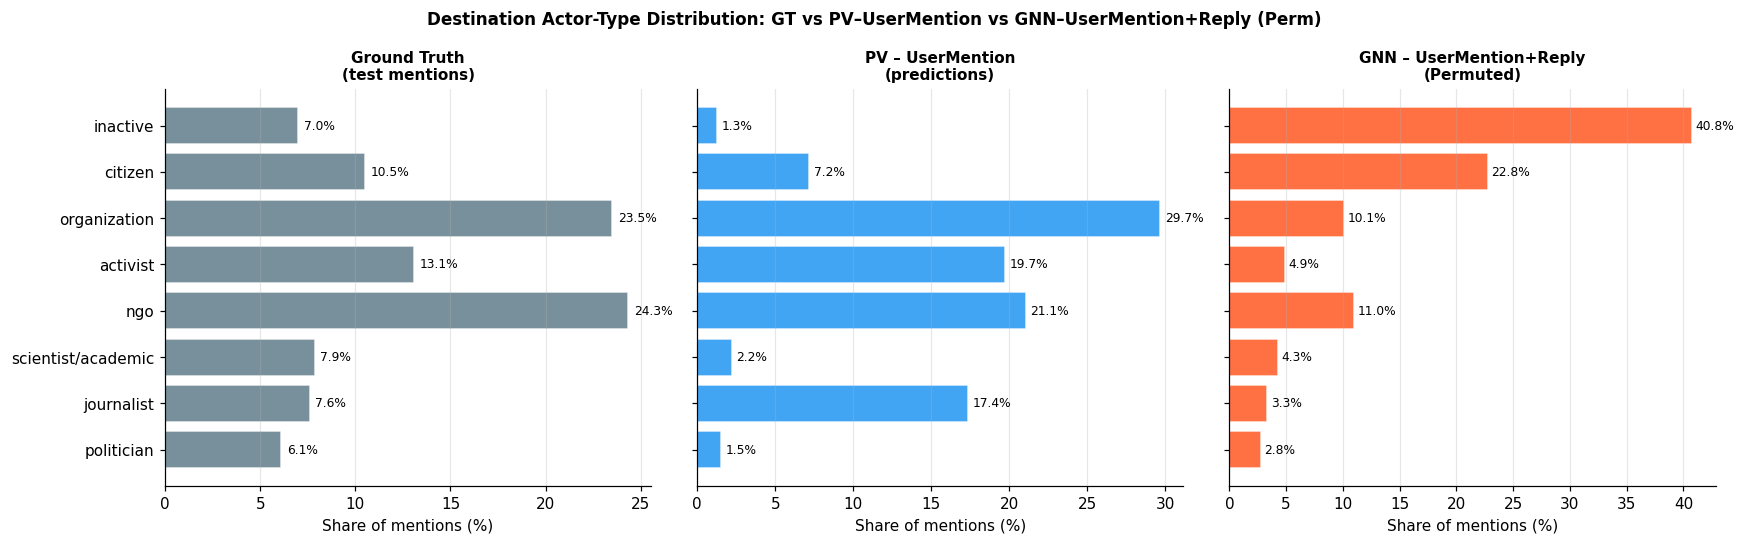


=== B1: Actor-type share (%) — 3 conditions ===
                      GT  PV-UserMention  GNN-UM+Reply(Perm)  GT vs PV delta  GT vs GNN delta
actor_type                                                                                   
politician           6.1             1.5                 2.8            -4.6             -3.3
journalist           7.6            17.4                 3.3             9.8             -4.3
scientist/academic   7.9             2.2                 4.3            -5.7             -3.6
ngo                 24.3            21.1                11.0            -3.3            -13.4
activist            13.1            19.7                 4.9             6.6             -8.2
organization        23.5            29.7                10.1             6.2            -13.4
citizen             10.5             7.2                22.8            -3.3             12.3
inactive             7.0             1.3                40.8            -5.7             33.8

Saved: act

In [54]:
# B1 (Revised) – GT vs PV–UserMention vs GNN–UserMention+Reply (Permuted)
# Three conditions only; all in one figure.
# Fix: use global lowercase ACTOR_ORDER; use load_gnn_preds (all runs aggregated).

rdir_gnn_b1 = RESULT_DIRS['user_mention_reply_perm']
um_gnn_b1   = load_user_metadata(rdir_gnn_b1)
gnn_b1_preds = load_gnn_preds(rdir_gnn_b1, split='test', epoch_key='best_map')

three_conditions = {
    'Ground Truth\n(test mentions)':        actor_type_counts(gt_idx,       user_meta),
    'PV – UserMention\n(predictions)':      actor_type_counts(pv_um,        user_meta),
    'GNN – UserMention+Reply\n(Permuted)':  actor_type_counts(gnn_b1_preds, um_gnn_b1),
}

CONDITION_COLORS = ['#607D8B', PV_COLOR, GNN_COLOR]   # grey / blue / orange

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(
    'Destination Actor-Type Distribution: GT vs PV–UserMention vs GNN–UserMention+Reply (Perm)',
    fontsize=11, fontweight='bold'
)

for ax, (title, dist), color in zip(axes, three_conditions.items(), CONDITION_COLORS):
    # dist is already indexed by global ACTOR_ORDER (lowercase) from actor_type_counts()
    bars = ax.barh(dist.index, dist.values * 100, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Share of mentions (%)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, dist.values):
        if val > 0.005:
            ax.text(val * 100 + 0.3, bar.get_y() + bar.get_height() / 2,
                    f'{val:.1%}', va='center', fontsize=8)

fig.tight_layout()
fig.savefig(OUT / 'actor_type_comparison_3cond.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)

# Summary table
df_3 = pd.DataFrame(three_conditions)
df_3.index.name = 'actor_type'
df_3.columns = ['GT', 'PV-UserMention', 'GNN-UM+Reply(Perm)']
df_3['GT vs PV delta'] = df_3['PV-UserMention'] - df_3['GT']
df_3['GT vs GNN delta'] = df_3['GNN-UM+Reply(Perm)'] - df_3['GT']
print('\n=== B1: Actor-type share (%) — 3 conditions ===')
print((df_3 * 100).round(1).to_string())
df_3.to_csv(OUT / 'actor_type_shares_3cond.csv', float_format='%.4f')
print(f'\nSaved: actor_type_comparison_3cond.png + actor_type_shares_3cond.csv')


## Prediction bias: nomination rate and root causes

Test table rows: 18,977 | validated=False | PV MAP@10=0.0201

Top-15 most-mentioned users in full dataset (N=329,920 mentions):
       username              actor  count      pct
  gretathunberg           activist   3817 1.156947
             un                ngo   2946 0.892944
         unfccc       organization   2155 0.653189
    extinctionr           activist   1452 0.440107
        nytimes         journalist   1360 0.412221
            wef       organization   1359 0.411918
        ipcc_ch       organization   1337 0.405250
       guardian         journalist   1053 0.319168
  unenvironment                ngo   1034 0.313409
realdonaldtrump            citizen    943 0.285827
            epa                ngo    907 0.274915
            aoc         journalist    738 0.223691
      antgrasso scientist/academic    733 0.222175
antonioguterres         politician    731 0.221569
  mikequindazzi       organization    693 0.210051

=== B1b: Bias analysis summary ===
                    

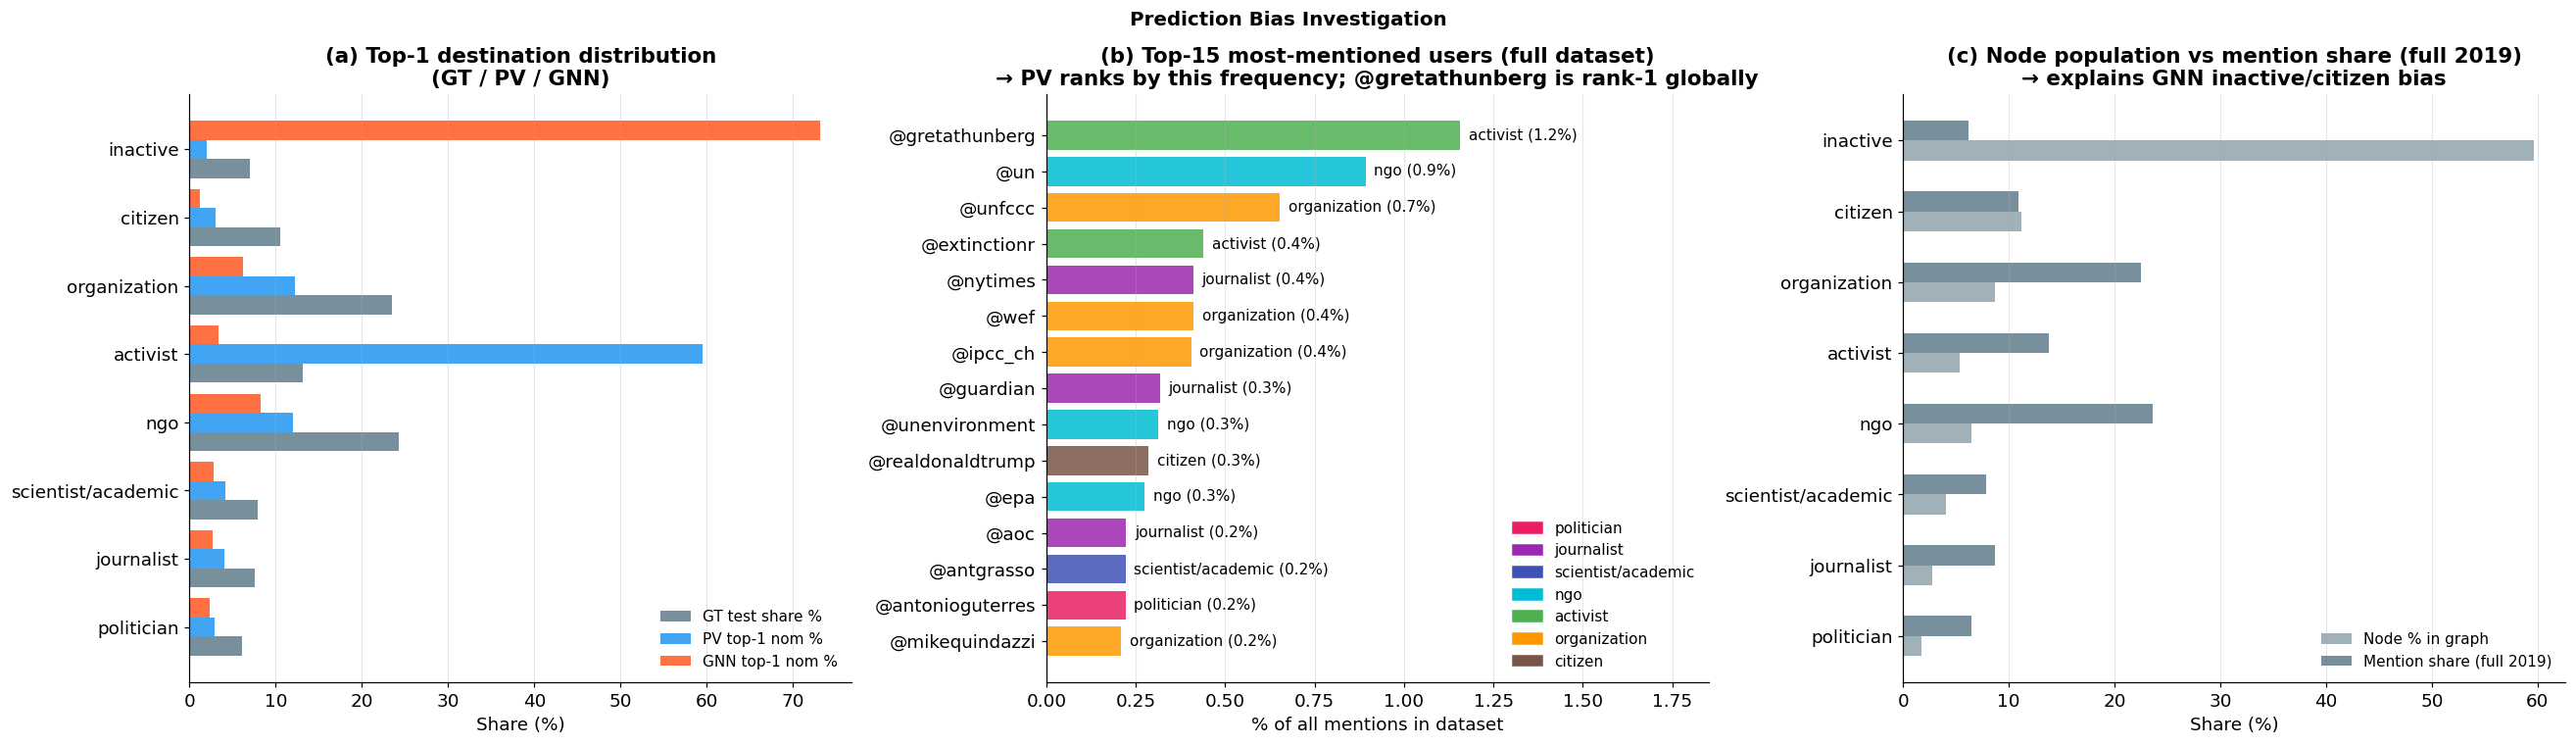

Saved: b1b_bias_investigation.png + b1b_bias_investigation.csv


In [63]:
# B1b – Prediction bias: 4-panel analysis

# ── 0. Reconstruct per-user test table (rows aligned with pv_um) ─────────────
test_df, validated, pv_map_check = reconstruct_user_mention_test_table(results_um)
n = min(len(test_df), len(pv_um))
test_df  = test_df.iloc[:n].copy()
pv_r1    = pv_um[:n, 0].astype(int)         # top-1 PV prediction per source user
gnn_r1   = gnn_b1_preds[:n, 0].astype(int)  # top-1 GNN prediction (nomination only)
print(f"Test table rows: {n:,} | validated={validated} | PV MAP@10={pv_map_check:.4f}")

# ── 1. top-1 nomination distributions ────────────────────────────────────────
gt_share   = actor_type_counts(gt_idx,  user_meta).reindex(ACTOR_ORDER) * 100
pv_share   = actor_type_counts(pv_r1,   user_meta).reindex(ACTOR_ORDER) * 100
gnn_share  = actor_type_counts(gnn_r1, um_gnn_b1).reindex(ACTOR_ORDER) * 100

# ── 2. Top-15 most-mentioned users in full dataset (PV bias root cause) ───────
top_k = 15
mr_freq = load_mention_rel()                        # all 329k mention rows
total_mentions = len(mr_freq)
dst_counts = mr_freq['user_idx'].value_counts()     # 'user_idx' col = destination username
top_train_df = dst_counts.head(top_k).reset_index()
top_train_df.columns = ['username', 'count']
top_train_df['pct'] = top_train_df['count'] / total_mentions * 100
uname_to_actor = user_meta.reset_index().set_index('username')['actor_type']
top_train_df['actor'] = top_train_df['username'].map(uname_to_actor).fillna('unknown')
print(f"\nTop-{top_k} most-mentioned users in full dataset (N={total_mentions:,} mentions):")
print(top_train_df[['username','actor','count','pct']].to_string(index=False))

# ── 3. Node population share + full-dataset mention share ────────────────────
node_share = user_meta['actor_type'].value_counts(normalize=True).reindex(ACTOR_ORDER) * 100
# full-dataset mention share by destination actor type (reuse mr_freq from sec 2)
uname_to_idx = user_meta.reset_index().set_index('username')['user_idx'] if 'user_idx' in user_meta.reset_index().columns else None
# map destination username → actor type directly
dst_actor = mr_freq['user_idx'].map(uname_to_actor)   # uname_to_actor built in sec 2
full_mention_share = dst_actor.value_counts(normalize=True).reindex(ACTOR_ORDER) * 100

# ── 4. Summary table ──────────────────────────────────────────────────────────
df_b1b = pd.DataFrame({
    'GT test share (%)':  gt_share.round(1),
    'PV top-1 nom (%)':   pv_share.round(1),
    'GNN top-1 nom (%)':  gnn_share.round(1),
    'PV nom – GT (pp)':   (pv_share - gt_share).round(1),
    'GNN nom – GT (pp)':  (gnn_share - gt_share).round(1),
    'Node % in graph':    node_share.round(1),
})
print('\n=== B1b: Bias analysis summary ===')
print(df_b1b.to_string())
df_b1b.to_csv(OUT / 'b1b_bias_investigation.csv', float_format='%.2f')

# ── 5. Plot: 3-panel ──────────────────────────────────────────────────────────
FS_TITLE  = 14   # panel title
FS_LABEL  = 12   # axis labels
FS_TICK   = 12   # tick labels
FS_ANNOT  = 10    # bar annotations
FS_LEGEND = 10    # legend text
FS_SUPTITLE = 13

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Prediction Bias Investigation', fontsize=FS_SUPTITLE, fontweight='bold')
x = np.arange(len(ACTOR_ORDER)); w = 0.28

# Panel (a): top-1 destination distribution (GT / PV / GNN)
ax = axes[0]
ax.barh(x - w,  gt_share.values,  w, label='GT test share %',  color='#607D8B', alpha=0.85)
ax.barh(x,      pv_share.values,  w, label='PV top-1 nom %',   color=PV_COLOR,  alpha=0.85)
ax.barh(x + w,  gnn_share.values, w, label='GNN top-1 nom %',  color=GNN_COLOR, alpha=0.85)
ax.set_yticks(x); ax.set_yticklabels(ACTOR_ORDER, fontsize=FS_TICK)
ax.set_title('(a) Top-1 destination distribution\n(GT / PV / GNN)', fontsize=FS_TITLE, fontweight='bold')
ax.set_xlabel('Share (%)', fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND, frameon=False)
ax.spines[['top', 'right']].set_visible(False); ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='x', labelsize=FS_TICK)

# Panel (b): Top-15 most-mentioned users in full dataset (PV bias root cause)
ax = axes[1]
bar_labels = [f"@{row.username}" for _, row in top_train_df.iterrows()]
bar_colors = [ACTOR_COLORS.get(row.actor, '#BDBDBD') for _, row in top_train_df.iterrows()]
bars = ax.barh(range(top_k), top_train_df['pct'].values[::-1],
               color=bar_colors[::-1], alpha=0.85)
ax.set_yticks(range(top_k)); ax.set_yticklabels(bar_labels[::-1], fontsize=FS_TICK)
ax.set_title(f'(b) Top-{top_k} most-mentioned users (full dataset)\n'
             f'→ PV ranks by this frequency; @gretathunberg is rank-1 globally',
             fontsize=FS_TITLE, fontweight='bold')
ax.set_xlabel('% of all mentions in dataset', fontsize=FS_LABEL)
ax.tick_params(axis='x', labelsize=FS_TICK)
ax.spines[['top', 'right']].set_visible(False); ax.grid(axis='x', alpha=0.3)
# pad xlim so annotations stay inside axes
_max_pct = top_train_df['pct'].max()
ax.set_xlim(0, _max_pct * 1.6)
for bar, (_, row) in zip(bars, top_train_df.iloc[::-1].iterrows()):
    ax.text(bar.get_width() + _max_pct * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{row.actor} ({row.pct:.1f}%)", va='center', fontsize=FS_ANNOT)
legend_handles = [mpatches.Patch(color=ACTOR_COLORS[t], label=t)
                  for t in ACTOR_ORDER if t in top_train_df['actor'].values]
ax.legend(handles=legend_handles, fontsize=FS_LEGEND, frameon=False, loc='lower right')

# Panel (c): Node population share vs full-dataset mention share (GNN bias root cause)
ax = axes[2]
ax.barh(x - w/2, node_share.values,        w, label='Node % in graph',            color='#90A4AE', alpha=0.85)
ax.barh(x + w/2, full_mention_share.values, w, label='Mention share (full 2019)', color='#607D8B', alpha=0.85)
ax.set_yticks(x); ax.set_yticklabels(ACTOR_ORDER, fontsize=FS_TICK)
ax.set_title('(c) Node population vs mention share (full 2019)\n→ explains GNN inactive/citizen bias',
             fontsize=FS_TITLE, fontweight='bold')
ax.set_xlabel('Share (%)', fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND, frameon=False)
ax.tick_params(axis='x', labelsize=FS_TICK)
ax.spines[['top', 'right']].set_visible(False); ax.grid(axis='x', alpha=0.3)

fig.tight_layout()
fig.savefig(OUT / 'b1b_bias_investigation.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved: b1b_bias_investigation.png + b1b_bias_investigation.csv')

  All users                           9.31%
  GT                                  40.96%
  PV                                  75.42%
  GNN                                 17.44%


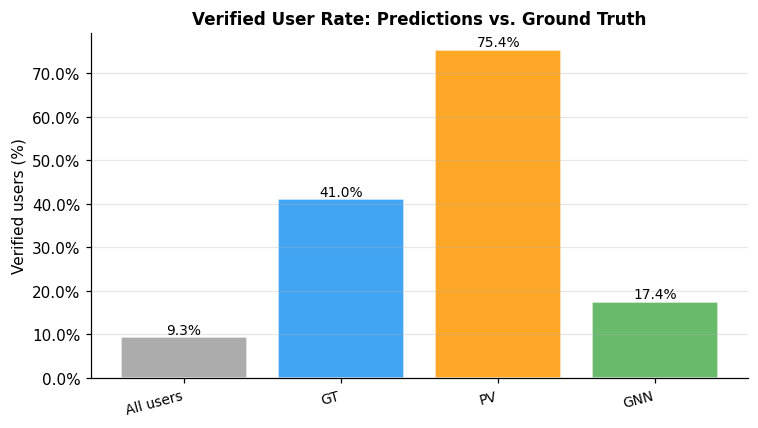

In [6]:
def verified_rate(idx_array, user_meta):
    return user_idx_to_meta(idx_array, user_meta)["verified"].mean()

verified_stats = {
    "All users":                 verified_rate(user_meta.index.values, user_meta),
    "GT":        verified_rate(gt_idx,  user_meta),
    # "PV – TweetMention (preds)": verified_rate(pv_tm,   user_meta),
    "PV":  verified_rate(pv_um,   user_meta),
    "GNN": verified_rate(gnn_b1_preds, um_gnn_b1),
}
for k, v in verified_stats.items():
    print(f"  {k:<35} {v:.2%}")

fig, ax = plt.subplots(figsize=(7, 4))
labels = list(verified_stats.keys())
vals   = [v * 100 for v in verified_stats.values()]
colors = ["#9E9E9E", "#2196F3", "#FF9800", "#4CAF50"]
bars   = ax.bar(labels, vals, color=colors, edgecolor="white", alpha=0.85)
ax.set_ylabel("Verified users (%)")
ax.set_title("Verified User Rate: Predictions vs. Ground Truth",
             fontsize=11, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax.spines[["top","right"]].set_visible(False); ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=15, ha="right", fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "verified_breakdown.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)
pd.Series(verified_stats, name="verified_rate").to_csv(OUT / "verified_rates.csv", header=True)


## Cross-actor-type mention matrix (user_mention, test set)

Test mention pairs: 57,367


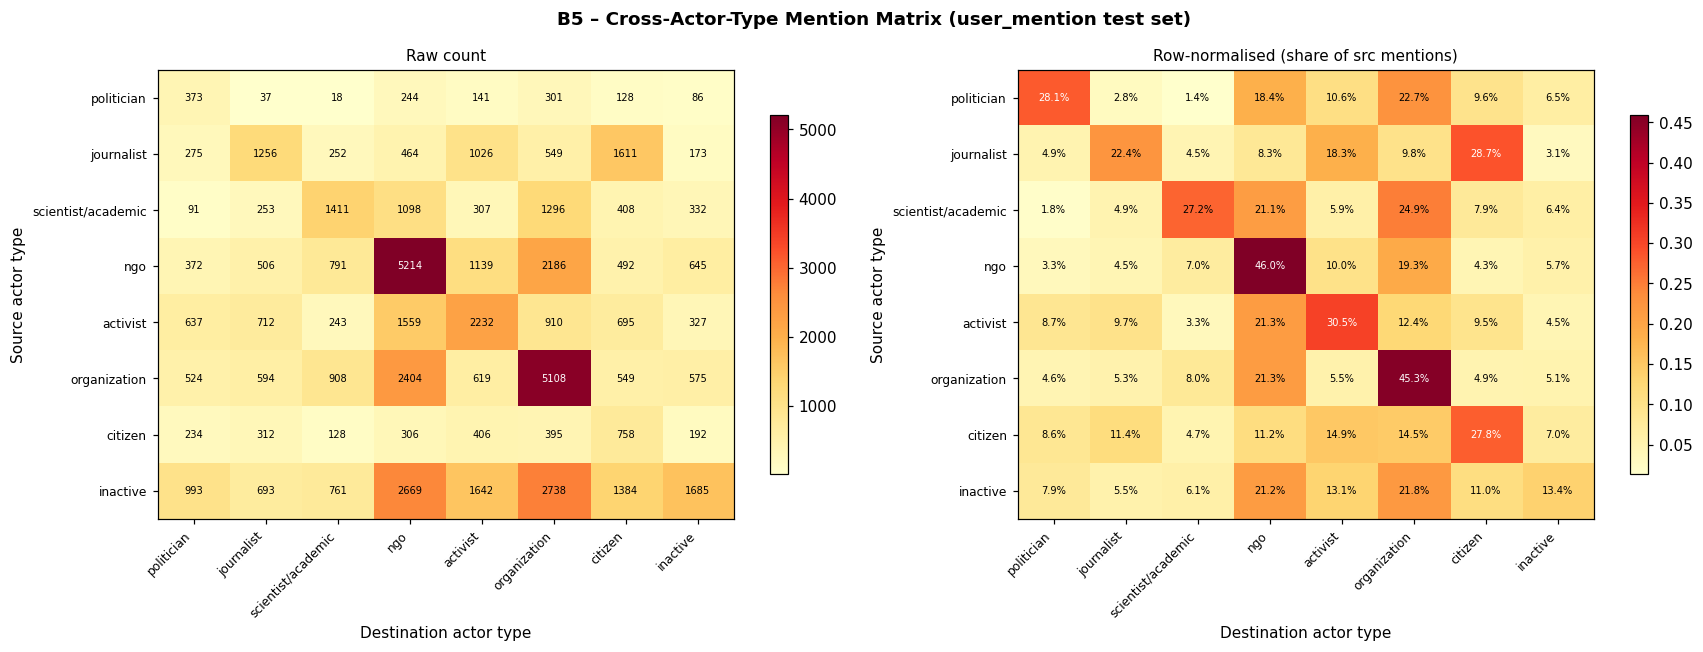

Saved actor_type_mention_matrix*.csv


In [9]:
# ── Build test mention pairs with actor types ─────────────────────────────────
tweet_meta_b   = load_tweet_metadata(results_um)
mr_all         = load_mention_rel()
_, _, test_mr_b = split_mention_rel(mr_all)

tm_b = tweet_meta_b.reset_index()
conv_to_author_b   = tm_b.set_index("conversation_id")["user_idx"].to_dict()
conv_to_tweetint_b = tm_b.set_index("conversation_id")["tweet_idx"].to_dict()
username_to_idx_b  = user_meta.reset_index().set_index("username")["user_idx"].to_dict()

test_pairs = test_mr_b.copy()
test_pairs["src_user_idx"]  = test_pairs["tweet_idx"].map(conv_to_author_b)
test_pairs["dst_user_idx"]  = test_pairs["user_idx"].map(username_to_idx_b)
test_pairs["tweet_int_idx"] = test_pairs["tweet_idx"].map(conv_to_tweetint_b)
test_pairs = test_pairs.dropna(subset=["src_user_idx", "dst_user_idx"])
test_pairs = test_pairs.astype({"src_user_idx": int, "dst_user_idx": int})

valid = test_pairs["src_user_idx"].isin(user_meta.index) & test_pairs["dst_user_idx"].isin(user_meta.index)
test_pairs = test_pairs[valid].copy()
test_pairs["src_actor"] = user_meta.loc[test_pairs["src_user_idx"].values, "actor_type"].values
test_pairs["dst_actor"] = user_meta.loc[test_pairs["dst_user_idx"].values, "actor_type"].values
test_pairs = test_pairs.dropna(subset=["src_actor", "dst_actor"])
print(f"Test mention pairs: {len(test_pairs):,}")

# ── B5: cross-actor-type matrix ───────────────────────────────────────────────
matrix_raw  = (test_pairs.groupby(["src_actor", "dst_actor"])
               .size().unstack(fill_value=0)
               .reindex(index=ACTOR_ORDER, columns=ACTOR_ORDER, fill_value=0))
matrix_norm = matrix_raw.div(matrix_raw.sum(axis=1).replace(0, 1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("B5 – Cross-Actor-Type Mention Matrix (user_mention test set)",
             fontsize=12, fontweight="bold")

for ax, (title, mat) in zip(axes, [
    ("Raw count",                              matrix_raw),
    ("Row-normalised (share of src mentions)", matrix_norm),
]):
    im = ax.imshow(mat.values, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(ACTOR_ORDER))); ax.set_xticklabels(ACTOR_ORDER, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(ACTOR_ORDER))); ax.set_yticklabels(ACTOR_ORDER, fontsize=8)
    ax.set_xlabel("Destination actor type"); ax.set_ylabel("Source actor type")
    ax.set_title(title, fontsize=10)
    for i in range(len(ACTOR_ORDER)):
        for j in range(len(ACTOR_ORDER)):
            val = mat.values[i, j]
            fmt = f"{val:.0f}" if mat is matrix_raw else f"{val:.1%}"
            ax.text(j, i, fmt, ha="center", va="center", fontsize=6.5,
                    color="white" if val > mat.values.max() * 0.6 else "black")
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.tight_layout()
fig.savefig(OUT / "actor_type_mention_matrix.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)
matrix_norm.to_csv(OUT / "actor_type_mention_matrix_normalised.csv", float_format="%.4f")
matrix_raw.to_csv(OUT / "actor_type_mention_matrix_raw.csv")
print("Saved actor_type_mention_matrix*.csv")

All-2019 mention pairs with actor labels: 329,920
  (test-only was: 57,367)


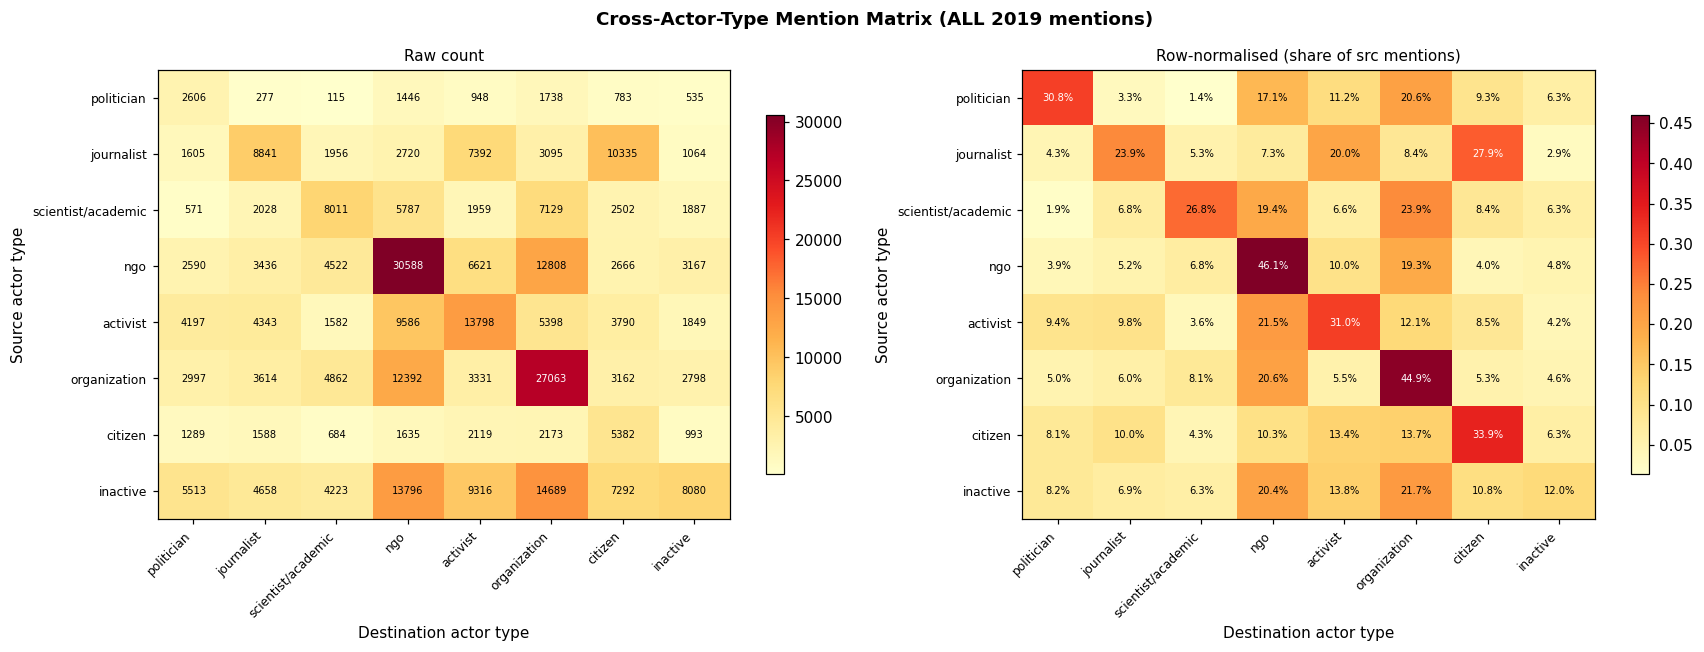

Saved actor_type_mention_matrix_all2019*.csv


In [10]:
# B5-all – Cross-actor-type mention matrix: ALL 2019 mentions (no test-mask restriction)
import warnings
warnings.filterwarnings('ignore')

mr_full_b = load_mention_rel().copy()   # all 329k mentions, 2019-01 → 2019-12
mr_full_b = mr_full_b.rename(columns={"user_idx": "dst_username"})

# Map tweet_idx (conversation_id string) → src author username
tm_b_all = tweet_meta_b.reset_index()   # tweet_meta_b already loaded above
conv_to_author_all = tm_b_all.set_index("conversation_id")["user_idx"].to_dict()

# Map username → integer user_idx (same dict as above)
all_pairs = mr_full_b.copy()
all_pairs["src_user_idx"] = all_pairs["tweet_idx"].map(conv_to_author_b)
all_pairs["dst_user_idx"] = all_pairs["dst_username"].map(username_to_idx_b)
all_pairs = all_pairs.dropna(subset=["src_user_idx", "dst_user_idx"])
all_pairs = all_pairs.astype({"src_user_idx": int, "dst_user_idx": int})

valid_all = (all_pairs["src_user_idx"].isin(user_meta.index) &
             all_pairs["dst_user_idx"].isin(user_meta.index))
all_pairs = all_pairs[valid_all].copy()
all_pairs["src_actor"] = user_meta.loc[all_pairs["src_user_idx"].values, "actor_type"].values
all_pairs["dst_actor"] = user_meta.loc[all_pairs["dst_user_idx"].values, "actor_type"].values
all_pairs = all_pairs.dropna(subset=["src_actor", "dst_actor"])

print(f"All-2019 mention pairs with actor labels: {len(all_pairs):,}")
print(f"  (test-only was: {len(test_pairs):,})")

# ── Build matrices ────────────────────────────────────────────────────────────
mat_all_raw  = (all_pairs.groupby(["src_actor", "dst_actor"])
                .size().unstack(fill_value=0)
                .reindex(index=ACTOR_ORDER, columns=ACTOR_ORDER, fill_value=0))
mat_all_norm = mat_all_raw.div(mat_all_raw.sum(axis=1).replace(0, 1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Cross-Actor-Type Mention Matrix (ALL 2019 mentions)",
             fontsize=12, fontweight="bold")

for ax, (title, mat) in zip(axes, [
    ("Raw count",                              mat_all_raw),
    ("Row-normalised (share of src mentions)", mat_all_norm),
]):
    im = ax.imshow(mat.values, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(ACTOR_ORDER)))
    ax.set_xticklabels(ACTOR_ORDER, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(ACTOR_ORDER)))
    ax.set_yticklabels(ACTOR_ORDER, fontsize=8)
    ax.set_xlabel("Destination actor type")
    ax.set_ylabel("Source actor type")
    ax.set_title(title, fontsize=10)
    for i in range(len(ACTOR_ORDER)):
        for j in range(len(ACTOR_ORDER)):
            val = mat.values[i, j]
            fmt = f"{val:.0f}" if mat is mat_all_raw else f"{val:.1%}"
            ax.text(j, i, fmt, ha="center", va="center", fontsize=6.5,
                    color="white" if val > mat.values.max() * 0.6 else "black")
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.tight_layout()
fig.savefig(OUT / "actor_type_mention_matrix_all2019.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

mat_all_norm.to_csv(OUT / "actor_type_mention_matrix_all2019_normalised.csv", float_format="%.4f")
mat_all_raw.to_csv(OUT / "actor_type_mention_matrix_all2019_raw.csv")
print("Saved actor_type_mention_matrix_all2019*.csv")
